# Chapter-10 Real-life: Visualizing sales Data usning the Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("Netflix_data.csv")
print(df)
df.head()
df.info()
print(df.isnull().sum())
df.describe()
df.head()
# now we cleaning the datatset romeve and fill the missing values:


     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# Basic understanding of the data set what we will do in this dataset
- project goal: what type of netflix have which type of movie have / which country produced how how much content/
* rating spreads:
  1. PG= Parental suggestion content
  2. R = Restricted content (mean the Only for the adults)
  3. TV-MA = Only for the mature audiance like (TV show)
  4. TV--14 = Parent strongly questioned
  ## steps to slove this project:
    1. load the Data: Read csv file with the help of  the pandas
    2. clean the data : handles the missng value, remove the duplicates, fix the columns if needed
    3. Understannd the data: use info(), head(), describe(), to explore the dataset
    4. Identify questions to answers: What do we want to know?(eg,; Movies vs TV shows, COntent rating, etc.)
    5. Visualize the data(EDA): use the Matplotlib to draw charts and the answer these questions visually.
    6. Save the plots: use plt.savefig() for your reports:
       

# Qusetion in for which we find the answers create the bar chart/ pie chart/scatter/subplots/histograms
- 1. how many movies vs tv shows are present on this ? --> use bar chart
  2. what is the number of the releases changed over the years? --> line plot
  3. what is the % of each content rating(pg, r, tv-ma)?--> use the pie chart
  4. what is the distribution of move duration?--> use histogram
  5. Relationship between release year and the number of shows?--> scatter plot(optional)
  6. Top 10 Countries with the highest number of shows?--> bar chart
  7. compare multiple plots together(eg, Moviesvs TV shows by the year)?--> Use subplots
  8. Save the final charts: use the plt.savefig()

     show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa 

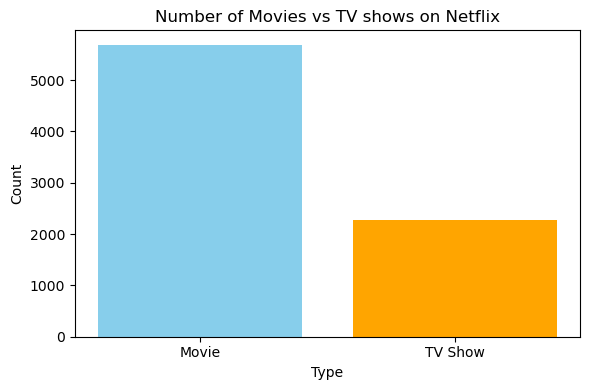

In [2]:
# step 1 import the lib.
df = pd.read_csv("Netflix_data.csv")
print(df)
df.head()
# now clean the data:
df = df.dropna(subset=['type', 'release_year','rating','country','duration'])
type_counts = df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_counts.index, type_counts.values, color=['skyblue','orange'])
plt.title('Number of Movies vs TV shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()

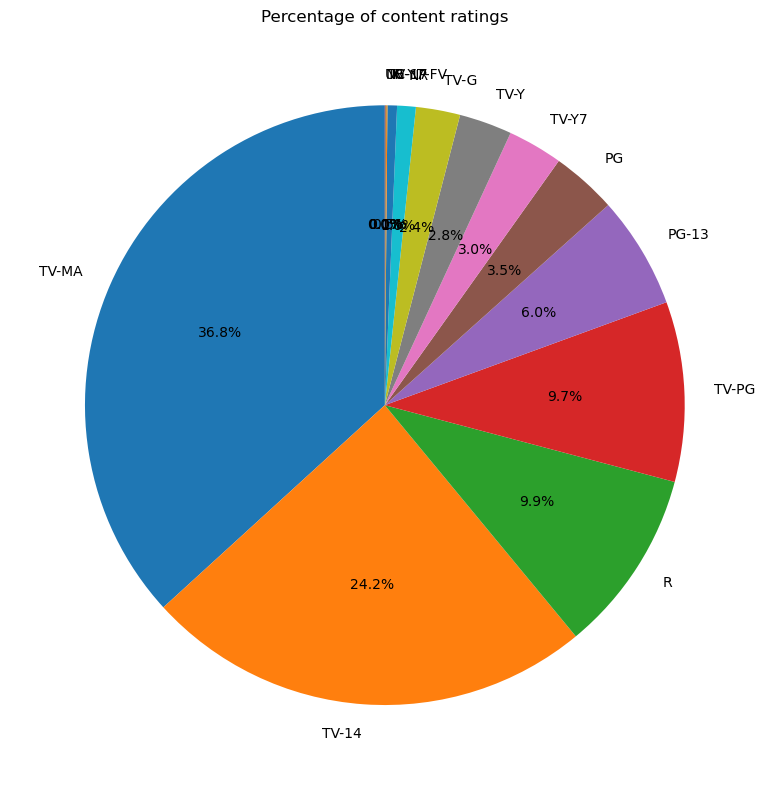

In [3]:
rating_counts = df['rating'].value_counts()
plt.figure(figsize=(10,8))
plt.pie(rating_counts, labels=rating_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Percentage of content ratings")
plt.tight_layout()
plt.savefig("Conent_rating_pie.png")
plt.show()


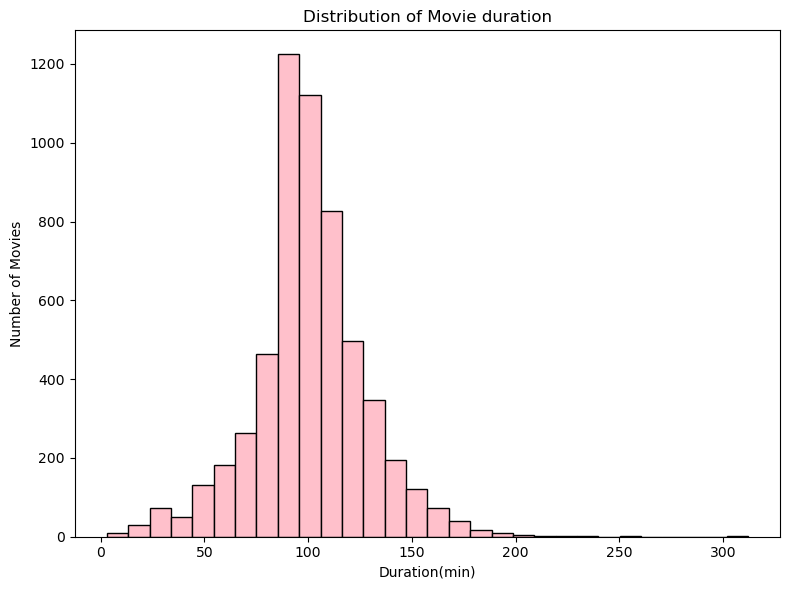

In [4]:
movie_df = df[df["type"] == "Movie"].copy()
movie_df["duration_int"] = movie_df["duration"].str.replace("min", "").astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df["duration_int"], bins=30, color="pink", edgecolor="black")
plt.title("Distribution of Movie duration")
plt.xlabel("Duration(min)")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("Movie_duartion_histogram.png")
plt.show()


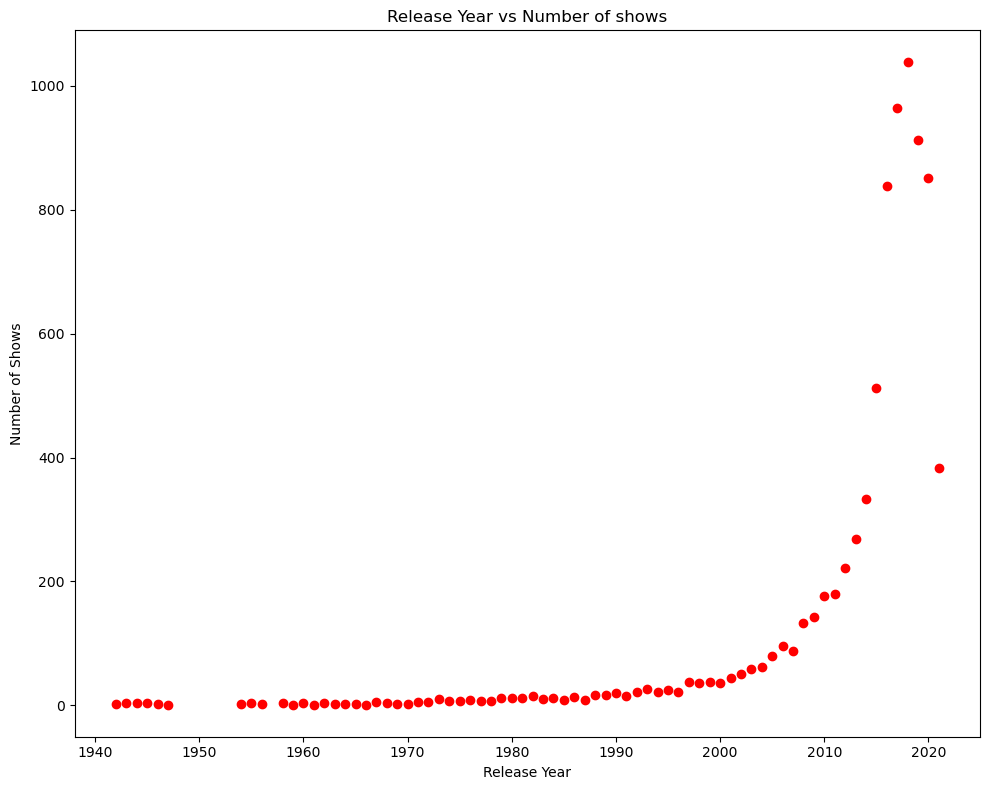

In [5]:
release_count = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(10,8))
plt.scatter(release_count.index, release_count.values, color="red")
plt.title("Release Year vs Number of shows")
plt.xlabel("Release Year")
plt.ylabel("Number of Shows")
plt.tight_layout()
plt.savefig("release_year_scatter.png")
plt.show()


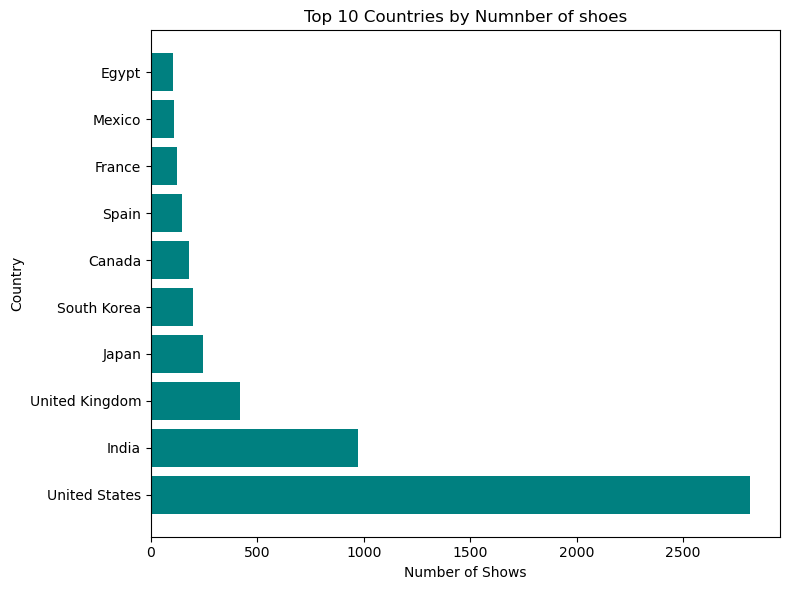

In [6]:
country_counts = df["country"].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index, country_counts.values, color="teal")
plt.title("Top 10 Countries by Numnber of shoes")
plt.xlabel("Number of Shows")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("Top10_countries.png")
plt.show()

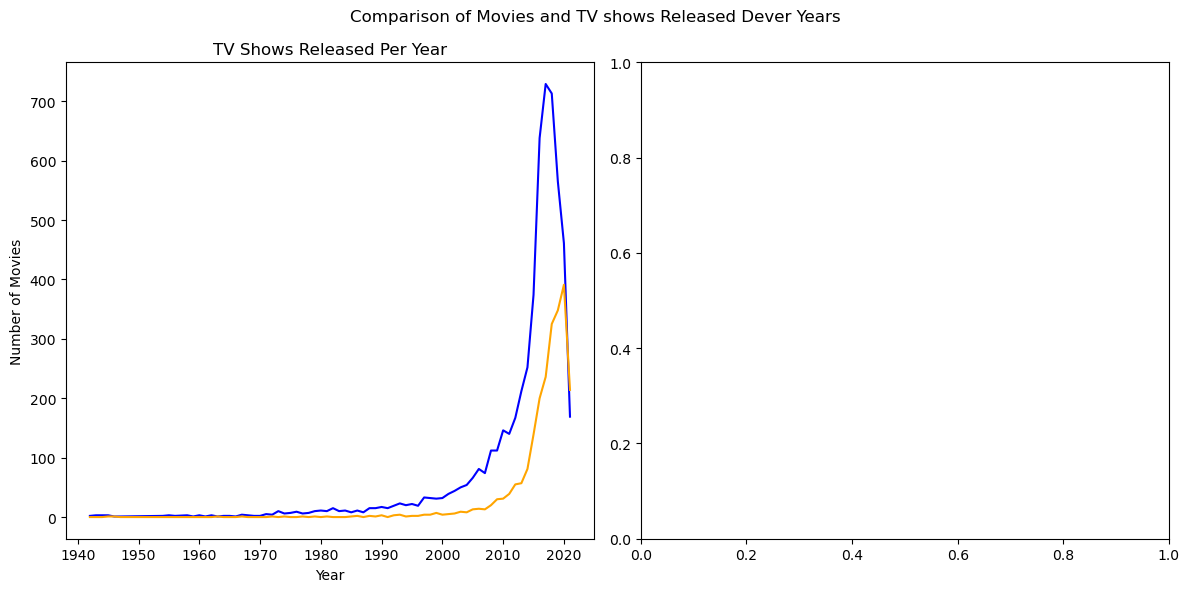

In [7]:
content_by_year = df.groupby(["release_year", "type"]).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2, figsize=(12,6))
# first subplot:movies
ax[0].plot(content_by_year.index, content_by_year["Movie"], color="blue")
ax[0].set_title("Movies released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Movies")
# 2nd subplot:tv shows
ax[0].plot(content_by_year.index, content_by_year["TV Show"], color="orange")
ax[0].set_title("TV Shows Released Per Year")
ax[0].set_xlabel("Year")
ax[0].set_ylabel("Number of Movies")


fig.suptitle("Comparison of Movies and TV shows Released Dever Years")
plt.tight_layout()
plt.savefig("movie_tv_shows_comparison.png")
plt.show()